# Project: Teaching an LLM to Reason

## Grant Collings - March 14, 2026

In this project, you will teach an LLM to use step-by-step reasoning to answer the question: "How many X's are there in the word Y?"

Counting letters in a word is a surprisingly complex task for an LLM. Just as human beings would not be able to answer such a question for longer words without breaking down the word into its individual letters and then counting them, LLMs cannot be similarly expected to be able to respond without using smaller reasoning steps.

For example, to count the number of o's in the word room, one could use the following reasoning:

```
Question: How many of the letter "o" are there in the word "room"
Answer: 2
Response:

<reasoning>
Letter-by-letter spelling:
1. r - 0 o's so far
2. o - 1 o's so far
3. o - 2 o's so far
4. m - 2 o's so far

The letter "o" appears 2 times in the word "room".
</reasoning>
<answer>
2
</answer>
```

In this project we will use the reinforcement learning method GRPO (Group Relative Policy Optimization, of DeepSeek fame) to take a large language model that has been fine-tuned for following instructions and teach it how to break a word down into its letters and then count the requested letter.

We will complete the following steps:

* Set up the notebook
* Create a letter-counting dataset
* Create the reward functions
* Train the model
* View the results

NOTE: This notebook will have you focus on several important aspects of training a GPRO model using LoRA:

1. Configuring LoRA adapters for parameter-efficient fine tuning
2. Selecting reward functions that help the model efficiently find its way to the correct answer (also called reward shaping)
3. Finding hyperparameters that help the model increase the rewards earned more quickly and reliably
4. Learning how to start with smaller experiments and to work your way up to longer experiments.

## Set up the notebook

We'll install dependencies needed for the project, namely `unsloth` and `vllm`, which are useful for fine-tuning LLMs with even just 15GB of VRAM.

In [1]:
import os

# CUDA and compile settings — must be set before any imports
os.environ["LD_LIBRARY_PATH"] = (
    "/usr/lib/x86_64-linux-gnu:" +
    os.environ.get("LD_LIBRARY_PATH", "")
)
os.environ["UNSLOTH_VLLM_NO_FLASHINFER"] = "1"
os.environ["TORCH_COMPILE_DISABLE"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TORCH_CUDA_ARCH_LIST"] = "7.5"

import site, glob

user_site = site.getusersitepackages()

# --- Triton shims ---
triton_ops = os.path.join(user_site, "triton", "ops")
os.makedirs(triton_ops, exist_ok=True)

for fname, content in [
    ("__init__.py", "# Compatibility shim for triton 3.x\n"),
    ("matmul_perf_model.py",
     "def estimate_matmul_time(*args, **kwargs): return 0.0\n"
     "def get_best_config(*args, **kwargs): return None\n"),
]:
    fpath = os.path.join(triton_ops, fname)
    if not os.path.exists(fpath):
        with open(fpath, "w") as f:
            f.write(content)
        print(f"Recreated triton shim: {fname}")

# --- Cutlass sm_75 patches ---
compiler_file = os.path.join(
    user_site,
    "nvidia_cutlass_dsl/python_packages/cutlass/base_dsl/compiler.py"
)

if os.path.exists(compiler_file):
    with open(compiler_file, "r") as f:
        c = f.read()

    changed = False
    if 'GPUArch("")' in c:
        c = c.replace('GPUArch("")', 'GPUArch("sm_75")')
        changed = True
        print("Applied cutlass GPUArch patch")

    old_arch = '''        arch = (
            envar.arch
            if self.options[GPUArch].value == ""
            else self.options[GPUArch].value'''
    new_arch = '''        arch = (
            "sm_75"
            if self.options[GPUArch].value == ""
            else self.options[GPUArch].value'''

    if old_arch in c:
        c = c.replace(old_arch, new_arch)
        changed = True
        print("Applied cutlass arch fallback patch")

    if changed:
        with open(compiler_file, "w") as f:
            f.write(c)

print("✅ Environment ready")

✅ Environment ready


In [2]:
# Load ipython-autotime to see how long each cell take to run
# No changes needed in this cell

!pip install -q ipython-autotime
%load_ext autotime

time: 424 µs (started: 2026-03-14 15:19:31 +00:00)


In [10]:
# Verify we have enough GPU memory to run this project (at least 15360MiB)
# No changes needed in this cell

!nvidia-smi

Sat Mar 14 15:18:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   34C    P0             25W /   70W |     297MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os
# Disable vllm's advanced compilation features that don't work on T4 (compute 7.5)
os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"
os.environ["UNSLOTH_VLLM_NO_FLASHINFER"] = "1"
os.environ["VLLM_COMPILE_SIZES"] = ""
os.environ["VLLM_TORCH_COMPILE_LEVEL"] = "0"
os.environ["TORCH_COMPILE_DISABLE"] = "1"

import unsloth
from unsloth import FastLanguageModel
import torch

max_seq_length = 384

# LoRA rank = 16
# Reasoning: rank 16 balances learning capacity vs VRAM on a T4.
# Rank 8 is too small for structured reasoning patterns.
# Rank 32+ risks OOM during GRPO with multiple generations per step.
lora_rank = 16

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen2.5-3B-Instruct",
    max_seq_length=max_seq_length,
    load_in_4bit=True,
    fast_inference=True,
    max_lora_rank=lora_rank,
    gpu_memory_utilization=0.5,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=lora_rank,
    target_modules=[
        # Attention modules: control how model attends across tokens.
        # Required for learning position-sensitive reasoning (letter-by-letter).
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        # FFN modules: control feature transformation at each layer.
        # Including these gives extra capacity to learn the counting task.
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=lora_rank,
    use_gradient_checkpointing="unsloth",
)

print(f"✅ LoRA model ready | rank={lora_rank}")
print(f"✅ Trainable parameters: "
      f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-03-14 15:21:05.950292: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-14 15:21:05.968190: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773501665.989950   10643 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773501665.997147   10643 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773501666.015913   10643 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

🦥 Unsloth Zoo will now patch everything to make training faster!
INFO 03-14 15:21:51 [vllm_utils.py:724] Unsloth: Patching vLLM v1 graph capture
==((====))==  Unsloth 2026.3.4: Fast Qwen2 patching. Transformers: 4.57.6. vLLM: 0.17.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: vLLM loading unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit with actual GPU utilization = 49.14%
Unsloth: Your GPU has CUDA compute capability 7.5 with VRAM = 14.56 GB.
Unsloth: Using conservativeness = 1.0. Chunked prefill tokens = 384. Num Sequences = 32.
Unsloth: vLLM's KV Cache can use up to 4.76 GB. Also swap space = 0 GB.
Unsloth: Not an error, but `use_cudagraph` is not suppo

/voc/work/.local/lib/python3.10/site-packages/pydantic/type_adapter.py:605: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `enum` - serialized value may not be as expected [field_name='mode', input_value=3, input_type=int])
  return self.serializer.to_python(


WARNING 03-14 15:21:56 [arg_utils.py:1321] The global random seed is set to 0. Since VLLM_ENABLE_V1_MULTIPROCESSING is set to False, this may affect the random state of the Python process that launched vLLM.
INFO 03-14 15:21:57 [model.py:531] Resolved architecture: Qwen2ForCausalLM
WARNING 03-14 15:21:57 [model.py:1892] Casting torch.bfloat16 to torch.float16.
INFO 03-14 15:21:57 [model.py:1554] Using max model len 384
INFO 03-14 15:21:59 [scheduler.py:231] Chunked prefill is enabled with max_num_batched_tokens=4096.
Unsloth: vLLM Bitsandbytes config using kwargs = {'load_in_8bit': False, 'load_in_4bit': True, 'bnb_4bit_compute_dtype': 'float16', 'bnb_4bit_quant_storage': 'uint8', 'bnb_4bit_quant_type': 'nf4', 'bnb_4bit_use_double_quant': True, 'llm_int8_enable_fp32_cpu_offload': False, 'llm_int8_has_fp16_weight': False, 'llm_int8_skip_modules': ['lm_head', 'multi_modal_projector', 'merger', 'modality_projection', 'model.layers.2.mlp', 'model.layers.3.mlp', 'model.layers.30.mlp'], 'llm

...

INFO 03-14 15:24:34 [core.py:282] init engine (profile, create kv cache, warmup model) took 127.22 seconds
INFO 03-14 15:24:37 [llm.py:388] Supported tasks: ('generate',)
Unsloth: Just some info: will skip parsing ['attention_norm', 'input_layernorm', 'layer_norm1', 'q_norm', 'norm', 'post_attention_layernorm', 'k_norm', 'pre_feedforward_layernorm', 'ffn_norm', 'norm1', 'norm2', 'post_feedforward_layernorm', 'post_layernorm', 'layer_norm2']


Some weights of Qwen2ForCausalLM were not initialized from the model checkpoint at unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit and are newly initialized: ['lm_head.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Performing substitution for additional_keys=set()
Unsloth: Just some info: will skip parsing ['attention_norm', 'input_layernorm', 'layer_norm1', 'q_norm', 'norm', 'post_attention_layernorm', 'k_norm', 'cross_attn_input_layernorm', 'pre_feedforward_layernorm', 'cross_attn_post_attention_layernorm', 'ffn_norm', 'norm1', 'norm2', 'post_feedforward_layernorm', 'post_layernorm', 'layer_norm2']
unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.3.4 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


✅ LoRA model ready | rank=16
✅ Trainable parameters: 29,933,568
time: 4min 14s (started: 2026-03-14 15:20:29 +00:00)


## Try Prompt Engineering to Count Letters

Let's work on the system prompt a little to see if we can get the model to count the number of the letter `g` in `engage`.


Here you must:
* Write clear instructions
* Break the problem down into steps (Chain-of-Thought prompting)
* Provide at least one example for the model to follow (Few-shot prompting)

In [4]:
# First, let's see what happens when we have a blank system prompt
# No changes needed in this cell
SYSTEM_PROMPT = """"""
USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

# Convert the chat messages to a single string so the model can complete it
text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": USER_PROMPT,
        },
    ],
    tokenize=False,
    add_generation_prompt=True,
)

from vllm import SamplingParams

# Set the LLM sampling parameters
sampling_params = SamplingParams(
    temperature=0.8,
    top_p=0.95,
    max_tokens=2048,
)

# Generate the text completion
output = (
    model.fast_generate(
        [text_for_completion],
        sampling_params=sampling_params,
        lora_request=None,
    )[0]
    .outputs[0]
    .text
)

# Print the text input for the model and the model's output
print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(output)

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

=== TEXT FOR COMPLETION ===
<|im_start|>system
<|im_end|>
<|im_start|>user
How many of the letter "g" are there in the word "engage"<|im_end|>
<|im_start|>assistant

=== GENERATED OUTPUT ===
In the word "engage", there is only one letter "g".
time: 2.46 s (started: 2026-03-14 15:25:05 +00:00)


Without any prompting the model will generate an output such as this:

```
=== GENERATED OUTPUT ===
There is one letter "g" in the word "engage".
```

Now let's work on the system prompt to help the model break this problem down into steps, which might help it get the right answer (2 `g`'s in `engage`)

In [5]:
SYSTEM_PROMPT = """You are a letter-counting assistant. To count letters accurately,
you must spell out the word letter-by-letter, keeping a running count.

Here is an example:

Question: How many of the letter "o" are there in the word "room"?

<reasoning>
Letter-by-letter spelling:
1. r - 0 o's so far
2. o - 1 o's so far
3. o - 2 o's so far
4. m - 2 o's so far

The letter "o" appears 2 times in the word "room".
</reasoning>
<answer>
2
</answer>

Now follow the exact same steps for the next question."""

USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": USER_PROMPT},
    ],
    tokenize=False,
    add_generation_prompt=True,
)

from vllm import SamplingParams

sampling_params = SamplingParams(
    temperature=0.8,
    top_p=0.95,
    max_tokens=2048,
)

output = (
    model.fast_generate(
        [text_for_completion],
        sampling_params=sampling_params,
        lora_request=None,
    )[0]
    .outputs[0]
    .text
)

print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(output)

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

=== TEXT FOR COMPLETION ===
<|im_start|>system
You are a letter-counting assistant. To count letters accurately,
you must spell out the word letter-by-letter, keeping a running count.

Here is an example:

Question: How many of the letter "o" are there in the word "room"?

<reasoning>
Letter-by-letter spelling:
1. r - 0 o's so far
2. o - 1 o's so far
3. o - 2 o's so far
4. m - 2 o's so far

The letter "o" appears 2 times in the word "room".
</reasoning>
<answer>
2
</answer>

Now follow the exact same steps for the next question.<|im_end|>
<|im_start|>user
How many of the letter "g" are there in the word "engage"<|im_end|>
<|im_start|>assistant

=== GENERATED OUTPUT ===
<reasoning>
Letter-by-letter spelling:
1. e - 0 g's so far
2. a - 0 g's so far
3. n - 0 g's so far
4. g - 1 g's so far
5. e - 1 g's so far
6. a - 1 g's so far
7. n - 1 g's so far

The letter "g" appears 1 time in the word "engage".
</reasoning>
<answer>
1
</answer>
time: 2.7 s (started: 2026-03-14 15:25:18 +00:00)


Did your new prompt get the right answer? Did the model follow all of your instructions?

Maybe yes, maybe no. Either way, we'll want the model to reliably complete this challenge. So let's use GRPO to help it!

## Create a letter-counting dataset

To train a model, we'll first need to create a dataset. We'll use the HuggingFace `datasets` package.

In [6]:
# Create a list of words of different lengths
# No changes are needed in this cell.

ALL_WORDS = [
    "idea",
    "glow",
    "rust",
    "maze",
    "echo",
    "wisp",
    "veto",
    "lush",
    "gaze",
    "knit",
    "fume",
    "plow",
    "void",
    "oath",
    "grim",
    "crisp",
    "lunar",
    "fable",
    "quest",
    "verge",
    "brawn",
    "elude",
    "aisle",
    "ember",
    "crave",
    "ivory",
    "mirth",
    "knack",
    "wryly",
    "onset",
    "mosaic",
    "velvet",
    "sphinx",
    "radius",
    "summit",
    "banner",
    "cipher",
    "glisten",
    "mantle",
    "scarab",
    "expose",
    "fathom",
    "tavern",
    "fusion",
    "relish",
    "lantern",
    "enchant",
    "torrent",
    "capture",
    "orchard",
    "eclipse",
    "frescos",
    "triumph",
    "absolve",
    "gossipy",
    "prelude",
    "whistle",
    "resolve",
    "zealous",
    "mirage",
    "aperture",
    "sapphire",
]

print(len(ALL_WORDS))

ALL_WORDS[:10]

62


['idea',
 'glow',
 'rust',
 'maze',
 'echo',
 'wisp',
 'veto',
 'lush',
 'gaze',
 'knit']

time: 3.52 ms (started: 2026-03-14 15:25:28 +00:00)


In [7]:
# Create the dataset as a Hugging Face Dataset using Dataset.from_generator
# No changes needed in this cell

from datasets import Dataset
import random


# Go through the letters from the words (as well as letters not in the words),
# and create a labelled dataset with all the different combinations.
# For example for the word gaze:
# 1. How many i's are in idea? <-- count should be 1
# 2. How many d's are in idea? <-- count should be 1
# 3. How many e's are in idea? <-- count should be 1
# 4. How many a's are in idea? <-- count should be 1
# 5. How many b's are in idea? <-- a letter not in word (count should be zero)
def generate_records():
    for word in ALL_WORDS:
        for letter in sorted(set(word)):
            yield {"words": word, "letters": letter, "counts": word.count(letter)}

        # pick random letters not in the word
        num_letters_not_in_word_left = int(len(word) // 7 + 1)

        random.seed(hash(word))

        all_letters = list("abcdefghijklmnopqrstuvwxyz")

        random.shuffle(all_letters)
        for letter in all_letters:
            if letter not in word:
                yield {"words": word, "letters": letter, "counts": 0}
                num_letters_not_in_word_left -= 1
            if num_letters_not_in_word_left == 0:
                break


ds = Dataset.from_generator(generate_records)

# Show the first item
ds[0]

{'words': 'idea', 'letters': 'a', 'counts': 1}

time: 341 ms (started: 2026-03-14 15:25:34 +00:00)


In [8]:
# Add the entire prompt (system + user) and the answer to the dataset
# We'll use a prompt that spells out the word letter-by-letter
# No changes needed in this cell

import re
from datasets import load_dataset, Dataset

# Simple CoT prompt (zero-shot)
SYSTEM_PROMPT = """
Respond in the following format:
<reasoning>
Counting the number of [letter_to_count]'s in the word [word]
1. [first letter] - [count of requested letter so far] so far
2. [second letter] - [count of requested letter so far] so far
...
</reasoning>
<answer>
[number]
</answer>
"""

ds = ds.map(
    lambda x: {  # type: ignore
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": 'How many of the letter "{}" are there in the word "{}"'.format(
                    x["letters"], x["words"]
                ),
            },
        ],
    }
)

ds[0]

{'words': 'idea',
 'letters': 'a',
 'counts': 1,
 'prompt': [{'content': "\nRespond in the following format:\n<reasoning>\nCounting the number of [letter_to_count]'s in the word [word]\n1. [first letter] - [count of requested letter so far] so far\n2. [second letter] - [count of requested letter so far] so far\n...\n</reasoning>\n<answer>\n[number]\n</answer>\n",
   'role': 'system'},
  {'content': 'How many of the letter "a" are there in the word "idea"',
   'role': 'user'}]}

time: 52 ms (started: 2026-03-14 15:25:41 +00:00)


In [9]:
# Let's see how well the model runs out-of-the-box
# No changes needed in this cell

text = tokenizer.apply_chat_template(
    ds[0]["prompt"], tokenize=False, add_generation_prompt=True
)

from vllm import SamplingParams

sampling_params = SamplingParams(
    temperature=0.8,
    top_p=0.95,
    max_tokens=1024,
)
output = (
    model.fast_generate(
        [text],
        sampling_params=sampling_params,
        lora_request=None,
    )[0]
    .outputs[0]
    .text
)

print(output)

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 1 so far
3. e - 2 so far
4. a - 3 so far
</reasoning>
<answer>
3
</answer>
time: 1.62 s (started: 2026-03-14 15:25:46 +00:00)


## Create Reward Functions

One goal of creating reward functions is to guide the model toward behaviors that help it reach its goal (counting the occurrences of a letter within a word) more easily. Since there is more than one way to carry out any step-by-step task (e.g. whether or not you use bullet points to separate your steps), there's a bit of judgement involved in choosing what behaviors to reward, i.e. how do we provide partial credit or "shape" our rewards?

In this case we will encourage the model to (whether or not this structure is best):
* use numbers for bullet points when spelling out the word
* to spell the word correctly
* to count the requested letter correctly
* to use the requested reasoning format
* to get the final answer correct.


### Numbering reward function

In [10]:
import re

def extract_letter_numbering(response):
    """Extract the numbers at the beginning of numbered lines.
    
    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    returns [1, 2, 3]
    """
    pattern = r"\n(\d+). [a-z]"
    matches = re.findall(pattern, response)
    if matches:
        return [int(m) for m in matches]
    return []

assert extract_letter_numbering("""
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
""") == [1, 2, 3, 4, 5]


def numbering_reward_func(completions, words, **kwargs) -> list[float]:
    """Reward correct sequential numbering, penalize out-of-order or extra lines."""
    responses = [completion[0]["content"] for completion in completions]

    res = []
    for response, word in zip(responses, words):
        reward = 0

        for ix, spell_number in enumerate(extract_letter_numbering(response)):
            line_number = ix + 1

            if spell_number == line_number:
                reward += 1.0   # correct in-order numbering
            else:
                reward -= 1.0   # out-of-order numbering

            if line_number > len(word):
                reward -= 1.0   # penalize continuing past word length

        res.append(reward / len(word))
    return res


res = numbering_reward_func(
    completions=[
        [{"content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
3. l - 2 so far
1. l - 2 so far
1. l - 2 so far
</reasoning>
<answer>2</answer>"""}],
        [{"content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
3. l - 2 so far
</reasoning>
<answer>2</answer>"""}],
    ],
    words=["goal", "goal"],
)
print(res)
assert res[1] > res[0], "The better response should have a higher reward"
print("✅ numbering_reward_func passed")

[-0.5, 0.5]
✅ numbering_reward_func passed
time: 4.11 ms (started: 2026-03-14 15:25:55 +00:00)


### Spelling reward function

In [11]:
def extract_spelling(response):
    """Extract the letters spelled out in the numbered list.
    
    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    4. l - 2 so far
    Returns 'goal'
    """
    pattern = r"\n\d+. ([a-z])"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)
    if matches:
        return "".join([m for m in matches])
    return ""

assert extract_spelling("""
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
""") == "goal"


def spelling_reward_func(completions, words, **kwargs) -> list[float]:
    """Reward correct spelling of the target word."""
    from collections import Counter

    responses = [completion[0]["content"] for completion in completions]
    res = []

    for word, response in zip(words, responses):
        reward = 0.0
        spelled = extract_spelling(response)

        # Large reward for exact match
        if spelled == word:
            reward += 5.0

        # Penalize length difference
        reward -= abs(len(spelled) - len(word)) * 1.0

        # Penalize letters in response not in target word
        spelled_counter = Counter(spelled)
        word_counter = Counter(word)
        for ch, cnt in spelled_counter.items():
            extra = max(0, cnt - word_counter.get(ch, 0))
            reward -= extra * 1.0

        # Penalize letters in target word missing from response
        for ch, cnt in word_counter.items():
            missing = max(0, cnt - spelled_counter.get(ch, 0))
            reward -= missing * 1.0

        res.append(reward)
    return res


res = spelling_reward_func(
    completions=[
        [{"content": """<reasoning>
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
5. l - 2 so far
</reasoning>
<answer>2</answer>"""}],
        [{"content": """<reasoning>
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
</reasoning>
<answer>2</answer>"""}],
    ],
    words=["goal", "goal"],
)
print(res)
assert res[1] > res[0], "The better response should have a higher reward"
print("✅ spelling_reward_func passed")

[-2.0, 5.0]
✅ spelling_reward_func passed
time: 2.72 ms (started: 2026-03-14 15:26:09 +00:00)


### Counting reward function

In [12]:

def get_resp_letters_and_counts(response):
    """Extract (letter, running_count) pairs from numbered lines."""
    pattern = r"\n(\d+)\. ([a-z])\D*(\d+)"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)
    if not matches:
        return []
    return [(matched_letter, matched_count_so_far)
            for _, matched_letter, matched_count_so_far in matches]

assert get_resp_letters_and_counts("""
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
""") == [("g", "1"), ("o", "1"), ("a", "2"), ("a", "2"), ("l", "2")]


def counting_reward_func(completions, letters, **kwargs) -> list[float]:
    """Reward accurate running counts of the target letter."""
    responses = [completion[0]["content"] for completion in completions]
    res = []

    for letter, response in zip(letters, responses):
        reward = 0
        letters_and_counts = get_resp_letters_and_counts(response)

        if not letters_and_counts:
            res.append(-1)
            continue

        actual_count = 0
        for resp_letter, resp_count in letters_and_counts:
            if letter == resp_letter:
                actual_count += 1

            # Reward accurate running count, penalize inaccurate
            if int(resp_count) == actual_count:
                reward += 1.0
            else:
                reward -= 1.0

        res.append(reward / len(letters_and_counts))
    return res


res = counting_reward_func(
    completions=[
        [{"content": """<reasoning>
1. g - 0 so far
2. o - 0 so far
3. a - 1 so far
4. a - 2 so far
5. l - 0 so far
</reasoning>
<answer>This is my answer.</answer>"""}],
        [{"content": """<reasoning>
1. g - 1 so far
2. o - 1 so far
3. a - 1 so far
4. a - 1 so far
5. l - 1 so far
</reasoning>
<answer>This is my answer.</answer>"""}],
    ],
    letters=["g", "g"],
)
print(res)
assert res[1] > res[0], "The better response should have a higher reward"
print("✅ counting_reward_func passed")

[-0.6, 1.0]
✅ counting_reward_func passed
time: 2.87 ms (started: 2026-03-14 15:26:15 +00:00)


### Formatting reward functions



In [13]:
def extract_xml_answer(text: str) -> str:
    """Extracts the string between <answer> and </answer> tags."""
    pattern = r"<answer>(.*?)</answer>"
    match = re.search(pattern, text, re.DOTALL)
    if match:
        return match.group(1).strip()
    return ""

assert extract_xml_answer("""
<reasoning>
This is my reasoning.
</reasoning>
<answer>SUPERCALIFRAGILISTICEXPIALIDOCIOUS</answer>
""") == "SUPERCALIFRAGILISTICEXPIALIDOCIOUS"


def format_reward_func(completions, **kwargs) -> list[float]:
    """Reward correct <reasoning>...</reasoning><answer>...</answer> format."""
    pattern = r"\s*<reasoning>.*?</reasoning>\s*<answer>.*?</answer>"
    res = []

    for completion in completions:
        reward = 0.0
        response = completion[0]["content"]

        # Reward for correct overall format
        match = re.match(pattern, response, flags=re.MULTILINE | re.DOTALL)
        if match:
            reward += 0.5

        # Additional reward if answer is a plain integer
        extracted_answer = extract_xml_answer(response)
        if extracted_answer.lstrip("-").isdigit():
            reward += 0.5

        res.append(reward)
    return res


res = format_reward_func(
    completions=[
        [{"content": "This is my answer"}],
        [{"content": "<reasoning>\nThis is my reasoning.\n</reasoning>\n<answer>\n3\n</answer>"}],
    ]
)
print(res)
assert res[1] > res[0], "The better response should have a higher reward"
print("✅ format_reward_func passed")

[0.0, 1.0]
✅ format_reward_func passed
time: 2.02 ms (started: 2026-03-14 15:26:20 +00:00)


### Task correctness reward function

In [14]:
def correct_answer_reward_func(prompts, completions, counts, **kwargs) -> list[float]:
    """Reward the final answer if it exactly matches the true count."""
    responses = [completion[0]["content"] for completion in completions]
    extracted_responses = [extract_xml_answer(r) for r in responses]

    print(f"""
{"-" * 20}
Question: {prompts[0][-1]["content"]}
Answer: {counts[0]}
Response: {responses[0]}
Extracted: {extracted_responses[0]}
Correct: {str(extracted_responses[0]) == str(counts[0])}!
    """)

    res = [
        2.0 if str(r) == str(a) else -1.0
        for r, a in zip(extracted_responses, counts)
    ]
    return res


res = correct_answer_reward_func(
    prompts=[
        [{"content": "How many..."}],
        [{"content": "How many..."}],
    ],
    completions=[
        [{"content": "<reasoning>.../reasoning>\n<answer>\n3\n</answer>"}],
        [{"content": "<reasoning>.../reasoning>\n<answer>\n3\n</answer>"}],
    ],
    letters=["g", "g"],
    counts=[0, 3],
)
print(res)
assert res[1] > res[0], "The better response should have a higher reward"
print("✅ correct_answer_reward_func passed")


--------------------
Question: How many...
Answer: 0
Response: <reasoning>.../reasoning>
<answer>
3
</answer>
Extracted: 3
Correct: False!
    
[-1.0, 2.0]
✅ correct_answer_reward_func passed
time: 1.39 ms (started: 2026-03-14 15:26:25 +00:00)


### List the reward functions

In [15]:
# List out the reward functions we will use
# No changes needed in this cell

REWARD_FUNCS = [
    numbering_reward_func,
    spelling_reward_func,
    counting_reward_func,
    format_reward_func,
    correct_answer_reward_func,
]

time: 413 µs (started: 2026-03-14 15:26:29 +00:00)


## Train the model

Now set up GRPO Trainer and configurations!

As you run the trainer, the goal is to see the various `reward` columns increase.

After 50 steps or more, you may notice some of the reward standard deviations begin to decrease, meaning that the different predictions are starting to converge on solutions that give similar rewards. If your model has learned the task, then you'll see the `correct_answer_reward_function` increase to its highest value (check the function to see what that is).

Here is an example, which successfully converged on a higher reward. Note, the values you see here will probably be different from yours, especially if your reward amounts are different.

| Step | Training Loss | reward   | reward_std | ... | kl      | rewards / correct_answer_reward_function / mean | rewards / correct_answer_reward_function / std |
|------|---------------|----------|------------|-----|---------|------------------------------------------|-----------------------------------------|
| 1    | 0.000000      | 7.961805 | 2.368493   | ... | 0.020369| 0.875000                                 | 1.024695                                |
| 2    | 0.000000      | 7.937500 | 1.352467   | ... | 0.016483| 0.875000                                 | 1.024695                                |
| 3    | 0.000000      | 1.894792 | 6.462189   | ... | 0.013677| 0.375000                                 | 0.806226                                |
| ...  | ...           | ...      | ...        | ... | ...     | ...                                      | ...                                     |
| 398  | 0.000100      | 13.000000| 0.000000   | ... | 0.088529| 2.000000                                 | 0.000000                                |
| 399  | 0.000100      | 13.000000| 0.000000   | ... | 0.088617| 2.000000                                 | 0.000000                                |
| 400  | 0.000100      | 13.000000| 0.000000   | ... | 0.096202| 2.000000                                 | 0.000000                                |


In [16]:
# Common GRPO training parameters
# learning_rate=5e-6: conservative for RL fine-tuning on a small model
# beta=0.001: low KL penalty allows more exploration early in training
# per_device_train_batch_size=8, num_generations=8:
#   batch_size/num_generations = 1 prompt per step, 8 completions each
#   This is the minimum viable setup for GRPO on a 15GB T4
# gradient_accumulation_steps=2: effectively doubles batch for stability

COMMON_GRPO_TRAINING_PARAMS = dict(
    learning_rate=5e-6,
    beta=0.001,
    per_device_train_batch_size=8,
    num_generations=8,
    gradient_accumulation_steps=2,
    adam_beta1=0.9,
    adam_beta2=0.99,
    weight_decay=0.1,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    optim="adamw_8bit",
    logging_steps=1,
    max_prompt_length=256,
    max_completion_length=200,
    num_train_epochs=1,
    save_steps=250,
    max_grad_norm=0.1,
    report_to="none",
    output_dir="outputs",
    use_vllm=True,
)
print("✅ GRPO parameters set")

✅ GRPO parameters set
time: 863 µs (started: 2026-03-14 15:26:33 +00:00)


### Quick train

Let's train the model for just 5 steps (`max_steps=5`). As it runs we can double check we've set up our prompts correctly before running for a longer amount of time.

In [17]:
# Train for just a few steps for a few minutes
# This will allow us to observe the results and make any changes to our reward functions
# before starting a longer run. Note, you won't see much change in the average.
# reward values
# No changes are needed here

from trl import GRPOConfig, GRPOTrainer

# Short train to check on reward functions
training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    # We'll just run for a modest 5 steps to make sure everything works and to
    # estimate the amount of time it will take to run the full training.
    max_steps=5,
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)
trainer_res = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 5
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 2 x 1) = 16
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)


WARNING 03-14 15:26:39 [input_processor.py:168] vLLM has deprecated support for supporting different tokenizers for different LoRAs. By default, vLLM uses base model's tokenizer. If you are using a LoRA with its own tokenizer, consider specifying `--tokenizer [lora_path]` to use the LoRA tokenizer.

--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. l - 1 so far
3. i - 1 so far
4. s - 1 so far
5. t - 1 so far
6. e - 1 so far
7. n - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,sampling / sampling_logp_difference / mean,sampling / sampling_logp_difference / max,sampling / importance_sampling_ratio / min,sampling / importance_sampling_ratio / mean,sampling / importance_sampling_ratio / max,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,-0.011100,3.076190,3.911459,102.437500,76.000000,174.000000,0.000000,102.437500,76.000000,174.000000,0,0,0,0,0,0.000000,0.937500,0.250000,-0.125000,3.344149,-0.361310,0.549571,1.000000,0.000000,1.625000,1.024695
2,-0.163300,4.864583,5.114832,71.812500,38.000000,99.000000,0.000000,71.812500,38.000000,99.000000,No Log,No Log,No Log,No Log,No Log,0.000011,0.831250,0.312983,0.937500,4.999583,0.283333,0.626454,1.000000,0.000000,1.812500,0.750000
3,0.023900,-1.246180,3.162427,91.812500,47.000000,137.000000,0.000000,91.812500,47.000000,137.000000,No Log,No Log,No Log,No Log,No Log,0.000007,0.968750,0.125000,-3.125000,3.703602,-0.214931,0.624130,1.000000,0.000000,0.125000,1.500000
4,0.000600,5.592709,0.917812,68.062500,57.000000,76.000000,0.000000,68.062500,57.000000,76.000000,No Log,No Log,No Log,No Log,No Log,0.000004,0.921875,0.119678,1.875000,3.304038,0.170833,0.500500,1.000000,0.000000,1.625000,1.024695
5,-0.110400,-2.351488,2.098437,84.250000,39.000000,102.000000,0.000000,84.250000,39.000000,102.000000,No Log,No Log,No Log,No Log,No Log,0.000013,0.863095,0.249034,-4.500000,2.366432,0.347917,0.640741,1.000000,0.000000,-0.062500,1.436141



--------------------
Question: How many of the letter "a" are there in the word "knack"
Answer: 1
Response: <reasoning>
Counting the number of a's in the word knack
1. k - 0 so far
2. n - 1 so far
3. a - 1 (ninth letter is 'a') so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    

--------------------
Question: How many of the letter "e" are there in the word "sapphire"
Answer: 1
Response: <reasoning>
Counting the number of e's in the word "sapphire"
1. s - 0 so far
2. a - 1 so far
3. p - 1 so far
4. a - 2 so far
5. p - 2 so far
6. h - 2 so far
7. a - 3 so far
8. y - 3 so far
</reasoning>
<answer>
3
</answer>
Extracted: 3
Correct: False!
    

--------------------
Question: How many of the letter "s" are there in the word "aisle"
Answer: 1
Response: <reasoning>
Counting the number of s's in the word aisle
1. a - 0 so far
2. i - 1 so far
3. s - 1 so far
4. l - 2 so far
5. e - 3 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    

-------------

available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'clip_ratio/low_mean', 'clip_ratio/low_min', 'clip_ratio/high_mean', 'clip_ratio/high_max', 'clip_ratio/region_mean', 'epoch', 'step'])


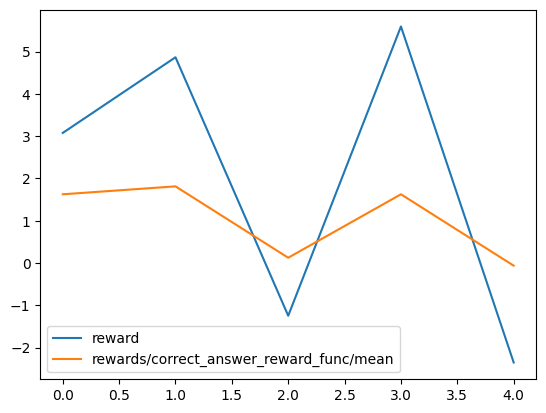

time: 598 ms (started: 2026-03-14 15:28:23 +00:00)


In [18]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)
# No changes needed in this cell

import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

### Slower train (1+ hour)

If everything looks good, let's go for a longer training session!

In [19]:
# Now let's train for real! Let's do a longer training that will take an hour or more
# Note: If this run is successful, you can consider doing a longer train
# to see what happens, but that's beyond the scope of this project.
# TODO: Fill out the areas where you find **********

# Full training
training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    # Configure the maximum number of steps to take about 30mins of time for
    # a medium-sized experiment. (See how long the previous example took and
    # scale up appropriately using your best guess.)
    max_steps= 200,  # ~60min
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)
trainer_res = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 2 x 1) = 16
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)



--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. l - 1 so far
3. i - 1 so far
4. s - 1 so far
5. t - 1 so far
6. e - 1 so far
7. n - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,sampling / sampling_logp_difference / mean,sampling / sampling_logp_difference / max,sampling / importance_sampling_ratio / min,sampling / importance_sampling_ratio / mean,sampling / importance_sampling_ratio / max,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,0.020600,3.060119,3.740938,105.250000,76.000000,174.000000,0.000000,105.250000,76.000000,174.000000,0,0,0,0,0,0.000018,0.937500,0.250000,-0.125000,3.263434,-0.377381,0.547621,1.000000,0.000000,1.625000,1.024695
2,-0.062200,1.848958,3.667574,73.875000,38.000000,111.000000,0.000000,73.875000,38.000000,111.000000,No Log,No Log,No Log,No Log,No Log,0.000063,0.778125,0.345432,-1.125000,4.287579,0.133333,0.682371,1.000000,0.000000,1.062500,1.436141
3,0.038100,-1.134722,3.490356,87.437500,65.000000,112.000000,0.000000,87.437500,65.000000,112.000000,No Log,No Log,No Log,No Log,No Log,0.000012,1.000000,0.000000,-2.562500,4.273465,-0.322222,0.605731,1.000000,0.000000,-0.250000,1.341641
4,0.021900,5.271875,1.200285,72.437500,57.000000,87.000000,0.000000,72.437500,57.000000,87.000000,No Log,No Log,No Log,No Log,No Log,0.000006,0.953125,0.100778,1.750000,3.415650,0.131250,0.424869,1.000000,0.000000,1.437500,1.209339
5,-0.154800,-2.575297,2.722912,82.937500,39.000000,102.000000,0.000000,82.937500,39.000000,102.000000,No Log,No Log,No Log,No Log,No Log,0.000014,0.785714,0.267967,-5.250000,2.294922,0.201488,0.527381,1.000000,0.000000,0.687500,1.537043
6,-0.135500,2.064980,5.632843,73.125000,38.000000,110.000000,0.000000,73.125000,38.000000,110.000000,No Log,No Log,No Log,No Log,No Log,0.000018,0.839286,0.345525,-0.937500,6.475274,0.663194,0.499702,1.000000,0.000000,0.500000,1.549193
7,-0.045200,0.797917,3.288825,79.062500,74.000000,86.000000,0.000000,79.062500,74.000000,86.000000,No Log,No Log,No Log,No Log,No Log,0.000008,0.906250,0.085391,-0.687500,4.045059,-0.170833,0.714700,1.000000,0.000000,-0.250000,1.341641
8,-0.017100,3.557292,1.868931,87.375000,83.000000,109.000000,0.000000,87.375000,83.000000,109.000000,No Log,No Log,No Log,No Log,No Log,0.000011,1.000000,0.000000,2.312500,3.300884,-0.317708,0.498348,1.000000,0.000000,-0.437500,1.209339
9,0.029600,8.086309,1.915879,83.187500,62.000000,117.000000,0.000000,83.187500,62.000000,117.000000,No Log,No Log,No Log,No Log,No Log,0.000007,1.000000,0.000000,4.562500,1.750000,0.273809,0.673718,1.000000,0.000000,1.250000,1.341641
10,0.006300,-1.412302,2.311471,80.937500,58.000000,112.000000,0.000000,80.937500,58.000000,112.000000,No Log,No Log,No Log,No Log,No Log,0.000011,0.636161,0.583535,-2.250000,2.516612,-0.360962,0.512800,1.000000,0.000000,-0.437500,1.209339



--------------------
Question: How many of the letter "a" are there in the word "knack"
Answer: 1
Response: <reasoning>
Counting the number of a's in the word knack
1. k - 0 so far
2. n - 1 so far
3. a - 1 (the first occurrence) + 1 (the previous count) = 2 so far
4. c - 2 so far
5. k - 2 so far
</reasoning>
<answer>
2
</answer>
Extracted: 2
Correct: False!
    

--------------------
Question: How many of the letter "e" are there in the word "sapphire"
Answer: 1
Response: <reasoning>
Counting the number of e's in the word "sapphire"
1. s - 0 so far
2. a - 1 so far
3. p - 1 so far
4. a - 2 so far
5. a - 3 so far
6. p - 3 so far
7. h - 3 so far
8. e - 4 so far
</reasoning>
<answer>
4
</answer>
Extracted: 4
Correct: False!
    

--------------------
Question: How many of the letter "s" are there in the word "aisle"
Answer: 1
Response: <reasoning>
Counting the number of s's in the word "aisle"
1. a - 0 so far
2. i - 0 so far
3. s - 1 so far
4. l - 1 so far
5. e - 1 so far
</reasoning>
<an

available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'clip_ratio/low_mean', 'clip_ratio/low_min', 'clip_ratio/high_mean', 'clip_ratio/high_max', 'clip_ratio/region_mean', 'epoch', 'step'])


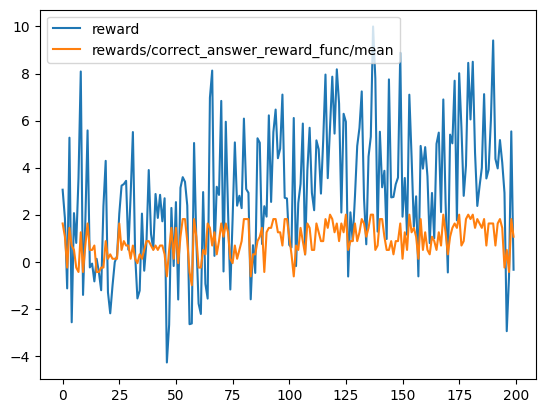

time: 315 ms (started: 2026-03-14 16:30:23 +00:00)


In [20]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)
# Do you see the rewards increasing? Does the model get the correct answer
# more frequently toward the end?
# No changes needed in this cell

import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

## View the results
Now let's try the model we just trained!

In [21]:
# Save the LoRA adapters
# No changes needed in this cell

# Save the LoRA model
model.save_lora("grpo_saved_lora")

time: 843 ms (started: 2026-03-14 16:30:32 +00:00)


In [22]:
# Create a function to run both the original model and the updated model
# No changes needed in this cell


def compare_old_and_new_model(messages):
    from vllm import SamplingParams

    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    sampling_params = SamplingParams(
        temperature=0.8,
        top_p=0.95,
        max_tokens=1024,
    )
    old = (
        model.fast_generate(
            text,
            sampling_params=sampling_params,
        )[0]
        .outputs[0]
        .text
    )

    new = (
        model.fast_generate(
            text,
            sampling_params=sampling_params,
            lora_request=model.load_lora("grpo_saved_lora"),
        )[0]
        .outputs[0]
        .text
    )

    print("===OLD===\n")
    print(old)

    print("\n\n===NEW===\n")
    print(new)


time: 994 µs (started: 2026-03-14 16:30:37 +00:00)


### Compare the old and new models on the letter-counting task

In [23]:
compare_old_and_new_model(ds[0]["prompt"])

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

===OLD===

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 1 so far
3. e - 2 so far
4. a - 3 so far
</reasoning>
<answer>
3
</answer>


===NEW===

<reasoning>
Counting the number of "a"s in the word "idea"
1. i - 0 so far
2. d - 0 so far
3. e - 0 so far
4. a - 1 so far
</reasoning>
<answer>
1
</answer>
time: 5.74 s (started: 2026-03-14 16:32:50 +00:00)


Our model is better at spelling and counter letters in words! Depending on your reward functions, the size of your model, and the amount of steps trained, results may vary.

For about an hour of training time, your model may not be perfect (or maybe it is), but it's definitely moving in the right direction!

### Make sure the model did not forget basic facts

In [24]:
compare_old_and_new_model([
    {"role": "system", "content": ""},
    {"role": "user", "content": "What is the capital of France?"}
])



Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

===OLD===

The capital of France is Paris.


===NEW===

The capital of France is Paris.
time: 1.86 s (started: 2026-03-14 16:33:36 +00:00)


Great job! Congrats on completing the project! 🎉🤗